In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/KOMAL/Desktop/Proj/Sleep_health_and_lifestyle_dataset.csv")
df.head(10)
#pd.set_option('display.max_rows',None)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [123]:
df.tail(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [124]:
df.shape

(374, 13)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [126]:
df.describe(include="all")

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


In [127]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [128]:
df1=df.copy()
df1.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [129]:
df1['Sleep Disorder'].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [130]:
# df1=df[~df.drop(['Person ID'], axis=1).duplicated()]

In [131]:
df_labeled = df1.dropna(subset=['Sleep Disorder']).copy()
df_unlabeled = df1[df1['Sleep Disorder'].isnull()].copy()

In [132]:
from sklearn.preprocessing import LabelEncoder

label_encoders={}
for col in df_labeled.select_dtypes(include=['object']).columns:
    le=LabelEncoder()
    df_labeled[col]=le.fit_transform(df_labeled[col])
    label_encoders[col]=le

In [133]:
for col, le in label_encoders.items():
    if col in df_unlabeled.columns:
        df_unlabeled[col] = df_unlabeled[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

In [134]:
X = df_labeled.drop(columns=['Sleep Disorder', 'Person ID'])
y = df_labeled['Sleep Disorder']

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [136]:
df1
#df_labeled
#df_unlabeled

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [137]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
logreg=LogisticRegression()
#logreg=LogisticRegression(random_state=42)

logreg.fit(X_train,y_train)
y_pred_logreg=logreg.predict(X_test)
accuracy_logreg=accuracy_score(y_test,y_pred_logreg)
print("Accuracy:",accuracy_logreg)
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))


Accuracy: 0.7741935483870968

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.79      0.76        14
           1       0.81      0.76      0.79        17

    accuracy                           0.77        31
   macro avg       0.77      0.78      0.77        31
weighted avg       0.78      0.77      0.77        31



c:\Users\KOMAL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [138]:
#Decision tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
dt=DecisionTreeClassifier()
#dt=DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)

dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Accuracy:",accuracy_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.8387096774193549

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



In [139]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# rf=RandomForestClassifier()
rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Accuracy:",accuracy_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

accuracy_rf1=accuracy_score(y_train,rf.predict(X_train))
print("Training Accuracy:",accuracy_rf1)


Accuracy: 0.8387096774193549

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31

Training Accuracy: 0.9596774193548387


In [140]:
#SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
svm=SVC()
#svm=SVC(kernel='linear',C=1.0,random_state=42)

svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print("Accuracy:",accuracy_svm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.5483870967741935

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67        14
           1       1.00      0.18      0.30        17

    accuracy                           0.55        31
   macro avg       0.75      0.59      0.48        31
weighted avg       0.77      0.55      0.47        31



In [141]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
knn=KNeighborsClassifier()
#knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)
accuracy_knn=accuracy_score(y_test,y_pred_knn)
print("Accuracy:",accuracy_knn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.7741935483870968

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80        14
           1       1.00      0.59      0.74        17

    accuracy                           0.77        31
   macro avg       0.83      0.79      0.77        31
weighted avg       0.85      0.77      0.77        31



In [142]:
#NaiveBayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
nb=GaussianNB()
nb.fit(X_train,y_train)
y_pred_nb=nb.predict(X_test)
accuracy_nb=accuracy_score(y_test,y_pred_nb)
print("Accuracy:",accuracy_nb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.7419354838709677

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.79      0.73        14
           1       0.80      0.71      0.75        17

    accuracy                           0.74        31
   macro avg       0.74      0.75      0.74        31
weighted avg       0.75      0.74      0.74        31



In [143]:
#Random Forest

y_pred_rf=rf.predict(X_test)
print("✅ Accuracy:",accuracy_score(y_test,y_pred_rf))
print("\nClassification Report:\n",classification_report(y_test,y_pred_rf))

✅ Accuracy: 0.8387096774193549

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



In [144]:
X_unlabeled=df_unlabeled.drop(columns=['Sleep Disorder','Person ID'])
predicted_labels=rf.predict(X_unlabeled)

In [145]:
le_target = label_encoders['Sleep Disorder']
predicted_labels_decoded = le_target.inverse_transform(predicted_labels)

In [146]:
df1.loc[df1['Sleep Disorder'].isnull(), 'Sleep Disorder'] = predicted_labels_decoded


In [147]:
df1['Sleep Disorder'].value_counts()

Sleep Disorder
Insomnia       261
Sleep Apnea    113
Name: count, dtype: int64

In [148]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [149]:
df['Sleep Disorder'].isnull().sum()

219

In [150]:
df.shape

(374, 13)

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
rf = RandomForestClassifier(random_state=42)

# Grid of hyperparameters to search over
param_grid = {
    'n_estimators': [100, 200, 300],        
    'max_depth': [None, 3, 5, 10, 15],         
    'min_samples_split': [10, 15],        
    'min_samples_leaf': [3,4, 5],          
    'max_features': ['sqrt', 'log2']        
}
# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv= StratifiedKFold(n_splits= 10, shuffle= True,random_state= 42),               
    n_jobs=-1,          
    verbose=2
)
print("Running Grid Search for Best Parameters...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\n Best Parameters Found:")
print(grid_search.best_params_)

y_pred_optimized = best_model.predict(X_test)
print("\n Optimized Model Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("\nClassification Report:\n", classification_report(y_test, y_pred_optimized))


Running Grid Search for Best Parameters...
Fitting 10 folds for each of 180 candidates, totalling 1800 fits


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [152]:
print("\n Optimized Model Accuracy:", accuracy_score(y_train, best_model.predict(X_train)))



 Optimized Model Accuracy: 0.9435483870967742


In [153]:
cols=df1.select_dtypes(include=['float64', 'int64'])
outliers={}
for col in cols:
    Q1=df1[col].quantile(0.25)
    Q3=df1[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers[col]=((df1[col]<lower)|(df1[col]>upper)).sum()
print("\nOutlier counts per column:")
print(pd.DataFrame.from_dict(outliers,orient="index",columns=["Outlier_Count"]))


Outlier counts per column:
                         Outlier_Count
Person ID                            0
Age                                  0
Sleep Duration                       0
Quality of Sleep                     0
Physical Activity Level              0
Stress Level                         0
Heart Rate                          15
Daily Steps                          0


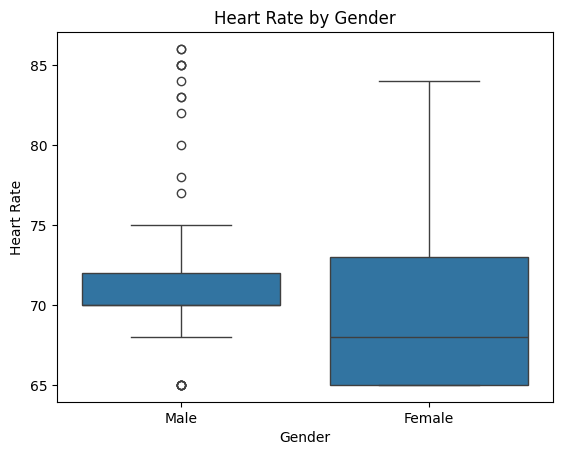

In [159]:
#plt.figure(figsize=(12,10))
sns.boxplot(data=df, y="Heart Rate", x="Gender")
plt.title("Heart Rate by Gender")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
rf = RandomForestClassifier(random_state=42)

# Grid of hyperparameters to search over
param_grid = {
    'n_estimators': [100, 200, 300],        
    'max_depth': [None, 3, 5, 10, 15],         
    'min_samples_split': [10, 15],        
    'min_samples_leaf': [3,4, 5],          
    'max_features': ['sqrt', 'log2']        
}
# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv= StratifiedKFold(n_splits= 10, shuffle= True,random_state= 42),               
    n_jobs=-1,          
    verbose=2
)
print("Running Grid Search for Best Parameters...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\n Best Parameters Found:")
print(grid_search.best_params_)

y_pred_optimized = best_model.predict(X_test)
print("\n Optimized Model Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("\nClassification Report:\n", classification_report(y_test, y_pred_optimized))
